# Customer Age Estimation Using Computer Vision

## Project Overview

This project develops a computer vision model to estimate a person's age from a facial image.

The business objective is to support age-related customer verification in a retail environment, including compliance with restrictions on the sale of age-restricted products. An automated age estimation system can serve as an additional decision-support tool for store employees.

The model uses transfer learning with a pretrained ResNet50 convolutional neural network. Performance is evaluated using Mean Absolute Error (MAE), with a project target of **MAE below 8 years**.

## Dataset

The dataset contains approximately **7,600 facial images** together with a CSV file containing:

- `file_name` — image filename
- `real_age` — actual age of the person in the image

Because the dataset contains thousands of images, image generators are used to load the data in batches instead of loading all images into memory at once.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Exploratory Data Analysis

In [3]:
data = pd.read_csv('/datasets/faces/labels.csv')

data.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [5]:
data.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


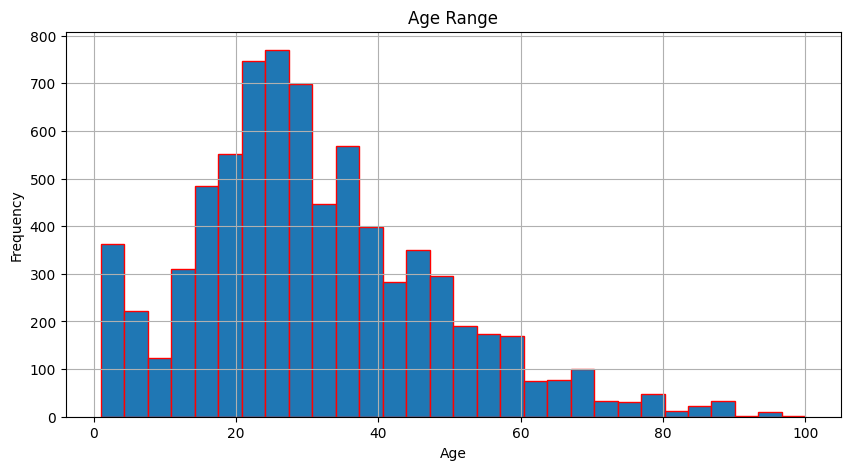

In [7]:
plt.figure(figsize=(10,5))

data['real_age'].hist(bins=30, edgecolor='red')

plt.title('Age Range')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

Found 7591 validated image filenames.


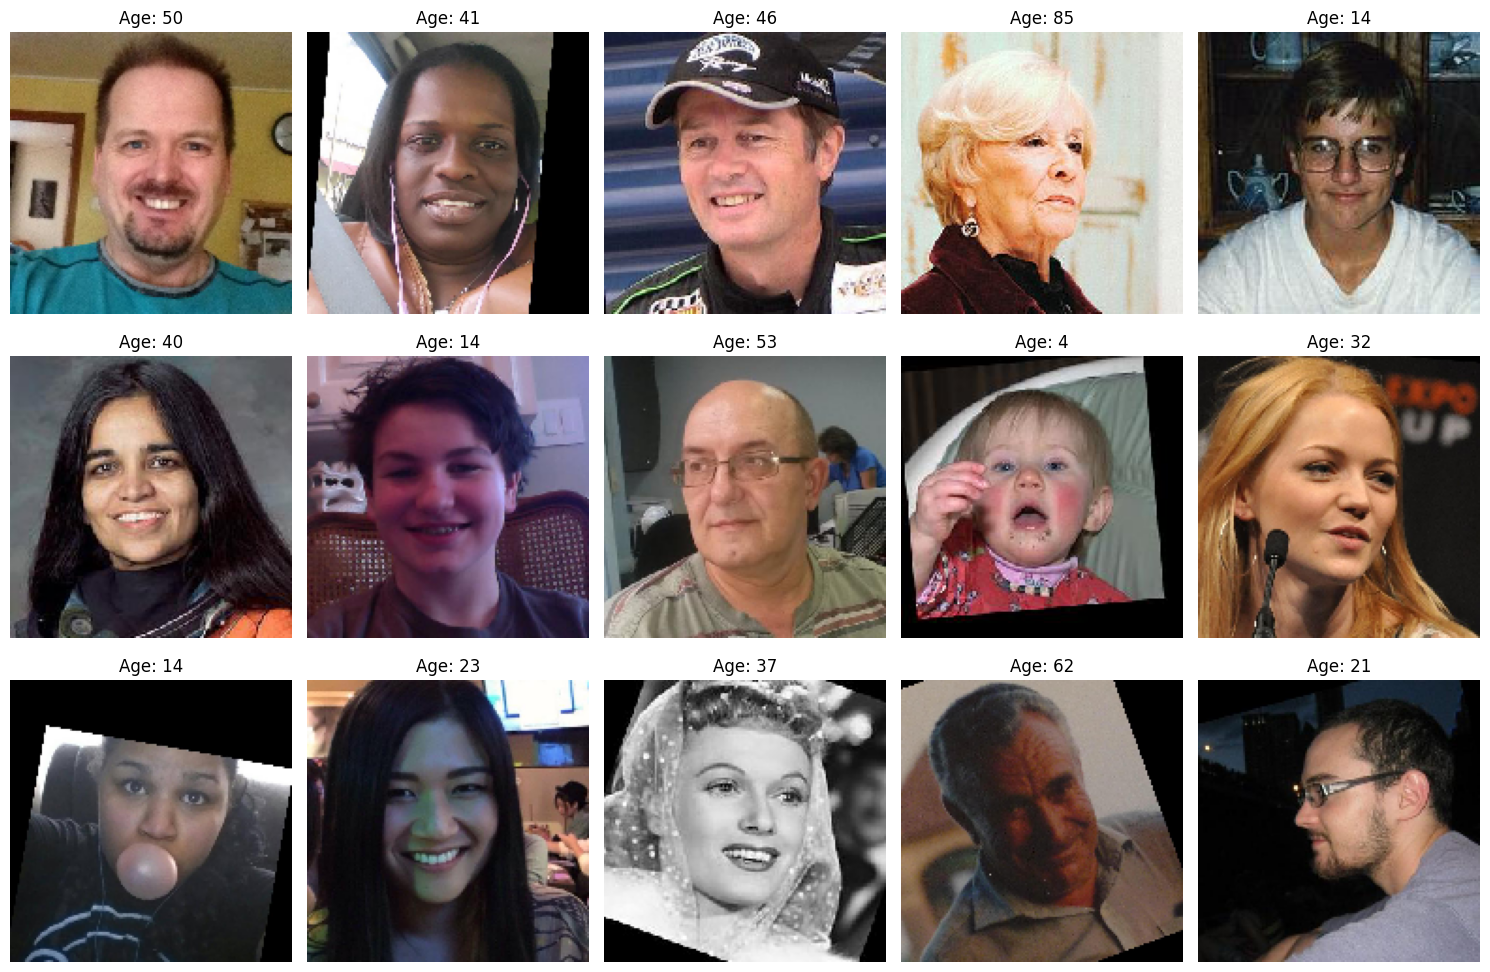

In [8]:
datagen = ImageDataGenerator(rescale=1./255)

gen_flow = datagen.flow_from_dataframe(
    dataframe=data,
    directory='/datasets/faces/final_files/',
    x_col='file_name',
    y_col='real_age',
    target_size=(150,150),
    batch_size=15,
    class_mode='raw',
    shuffle=True,
    seed=12345
)

features, target = next(gen_flow)

fig, axes = plt.subplots(3, 5, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(features[i])
    ax.set_title(f'Age: {int(target[i])}')
    ax.axis('off')
                 
                 
plt.tight_layout()
plt.show()

### EDA Findings

The dataset contains a wide range of ages, although younger and middle-aged individuals are more frequently represented than older age groups.

The sample images show variation in facial appearance, lighting, pose, and image quality, which makes age estimation a challenging computer vision problem.

Since age is a continuous numerical variable, this task is approached as a regression problem.

## Model Development

### Model Architecture

The model uses transfer learning with ResNet50 pretrained on ImageNet. The original classification head is removed and replaced with a global average pooling layer followed by a single output neuron for age prediction.

The images are resized to 150 × 150 pixels and normalized to the [0, 1] range. Horizontal flipping is applied to the training set as data augmentation.

The model is optimized using Adam with a learning rate of 0.0001. Mean Squared Error (MSE) is used as the loss function, while Mean Absolute Error (MAE) is used as the main evaluation metric.

In [ ]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam


def load_train(path):
    """
    Load the training subset of the image dataset.
    """
    
    datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255,
        horizontal_flip=True
    )
    
    train_gen_flow = datagen.flow_from_dataframe(
        dataframe=pd.read_csv(path + 'labels.csv'),
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(150, 150),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345
    )

    return train_gen_flow


def load_test(path):
    """
    Load the validation subset of the image dataset.
    """
    
    datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255
    )

    test_gen_flow = datagen.flow_from_dataframe(
        dataframe=pd.read_csv(path + 'labels.csv'),
        directory=path + 'final_files',
        x_col='file_name',
        y_col='real_age',
        target_size=(150, 150),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345
    )
    
    return test_gen_flow


def create_model(input_shape):
    """
    Create a ResNet50-based regression model for age estimation.
    """
    
    backbone = ResNet50(
        input_shape=input_shape,
        weights='imagenet',
        include_top=False
    )
    
    model = Sequential()
    
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))
    
    optimizer = Adam(learning_rate=0.0001)
    
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model


def train_model(
    model,
    train_data,
    test_data,
    batch_size=None,
    epochs=20,
    steps_per_epoch=None,
    validation_steps=None
):
    """
    Train the model using the training and validation image generators.
    """

    model.fit(
        train_data,
        validation_data=test_data,
        batch_size=batch_size,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2
    )

    return model

## Model Training and Results

The model was trained for 20 epochs using GPU acceleration.

The training set contained **5,694 images**, while the validation set contained **1,897 images**.

The target performance for the project was a validation MAE below **8 years**.

### Results

Found 5694 validated image filenames.
Found 1897 validated image filenames.

Epoch 1/20
356/356 - 128s - 358ms/step - loss: 236.5611 - mae: 11.1460 - val_loss: 636.8596 - val_mae: 19.9445

Epoch 2/20
356/356 - 86s - 241ms/step - loss: 93.8354 - mae: 7.3655 - val_loss: 164.1002 - val_mae: 9.7497

Epoch 3/20
356/356 - 42s - 118ms/step - loss: 67.2237 - mae: 6.2367 - val_loss: 116.7176 - val_mae: 8.1675

Epoch 4/20
356/356 - 43s - 122ms/step - loss: 53.4805 - mae: 5.5693 - val_loss: 92.3674 - val_mae: 7.4361

Epoch 5/20
356/356 - 43s - 120ms/step - loss: 41.2390 - mae: 4.8839 - val_loss: 75.8367 - val_mae: 6.6174

Epoch 6/20
356/356 - 43s - 120ms/step - loss: 31.7440 - mae: 4.2697 - val_loss: 76.0926 - val_mae: 6.6678

Epoch 7/20
356/356 - 44s - 123ms/step - loss: 25.6035 - mae: 3.8581 - val_loss: 76.4028 - val_mae: 6.4841

Epoch 8/20
356/356 - 81s - 227ms/step - loss: 22.1267 - mae: 3.5376 - val_loss: 70.2429 - val_mae: 6.2454

Epoch 9/20
356/356 - 44s - 124ms/step - loss: 19.2649 - mae: 3.3092 - val_loss: 83.1590 - val_mae: 6.5859

Epoch 10/20
356/356 - 43s - 121ms/step - loss: 16.9528 - mae: 3.1351 - val_loss: 67.5729 - val_mae: 6.0036

Epoch 11/20
356/356 - 49s - 137ms/step - loss: 14.4031 - mae: 2.8811 - val_loss: 80.1943 - val_mae: 6.9249

Epoch 12/20
356/356 - 43s - 121ms/step - loss: 13.6965 - mae: 2.8164 - val_loss: 65.8940 - val_mae: 6.1518

Epoch 13/20
356/356 - 44s - 123ms/step - loss: 14.5054 - mae: 2.8963 - val_loss: 84.8364 - val_mae: 6.7919

Epoch 14/20
356/356 - 43s - 121ms/step - loss: 13.9836 - mae: 2.8508 - val_loss: 69.0396 - val_mae: 6.0637

Epoch 15/20
356/356 - 83s - 232ms/step - loss: 12.8312 - mae: 2.7208 - val_loss: 73.6756 - val_mae: 6.5268

Epoch 16/20
356/356 - 43s - 121ms/step - loss: 11.6999 - mae: 2.6123 - val_loss: 67.6253 - val_mae: 6.1607

Epoch 17/20
356/356 - 49s - 137ms/step - loss: 10.5903 - mae: 2.4802 - val_loss: 70.6982 - val_mae: 6.1150

Epoch 18/20
356/356 - 44s - 123ms/step - loss: 10.6850 - mae: 2.4580 - val_loss: 69.6800 - val_mae: 6.2622

Epoch 19/20
356/356 - 43s - 122ms/step - loss: 11.0986 - mae: 2.5209 - val_loss: 66.4380 - val_mae: 5.9311

Epoch 20/20
356/356 - 43s - 121ms/step - loss: 11.1279 - mae: 2.5322 - val_loss: 71.8186 - val_mae: 6.3250

## Conclusion

In this project, a computer vision model was developed to estimate a person's age from facial images.

The dataset contained 7,591 images covering a wide range of ages. After exploring the data, the images were prepared using normalization and data augmentation with horizontal flipping.

A pretrained ResNet50 model was used with transfer learning and adapted for a regression task. The model was trained for 20 epochs using GPU acceleration.

The project required a validation MAE below 8 years. The model successfully exceeded this target, achieving its best validation MAE of approximately **5.93 years**, meaning that its age predictions were off by about 6 years on average.

Overall, the results show that transfer learning with ResNet50 can provide effective age estimation from facial images. However, an average error of approximately 6 years should be considered when applying the model to real-world age verification, especially for customers close to legal age thresholds.
